In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/algozee/smartphone-usage-and-addiction-analysis-dataset/Smartphone_Usage_And_Addiction_Analysis_7500_Rows.csv


# Problem Statement

- Many real-world datasets contain complex patterns that are difficult to analyze using traditional statistical methods.

- The goal is to use machine learning models to analyze the data, discover patterns, and make accurate predictions.

**Why AI Adoption Matters**

- AI can handle large and complex datasets efficiently.

- It can detect hidden relationships and trends in the data.

- AI models help in making better data-driven decisions and predictions.

**Objectives of this Notebook**

- Perform data cleaning and preprocessing.

- Conduct Exploratory Data Analysis (EDA) and visualization.

- Train multiple machine learning models.

- Compare model performance to find the best one.

- Generate insights and predictions from the dataset.

#  Import Libraries

In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from imblearn.over_sampling import SMOTE

#  Load Dataset

In [3]:

df = pd.read_csv('/kaggle/input/datasets/algozee/smartphone-usage-and-addiction-analysis-dataset/Smartphone_Usage_And_Addiction_Analysis_7500_Rows.csv')


#  EDA

In [4]:




print("Dataset Shape:", df.shape)
print("\nMissing Values:\n", df.isnull().sum())
print("\nDuplicate Rows:", df.duplicated().sum())
print("\nData Types:\n", df.dtypes)
print("\nSummary Statistics:\n", df.describe())

# Drop unnecessary columns
df.drop(columns=['transaction_id','user_id','addiction_level'], inplace=True)

# Encode categorical variables
le_gender = LabelEncoder()
df['gender'] = le_gender.fit_transform(df['gender'])

le_stress = LabelEncoder()
df['stress_level'] = le_stress.fit_transform(df['stress_level'])

le_academic = LabelEncoder()
df['academic_work_impact'] = le_academic.fit_transform(df['academic_work_impact'])

Dataset Shape: (7500, 16)

Missing Values:
 transaction_id               0
user_id                      0
age                          0
gender                       0
daily_screen_time_hours      0
social_media_hours           0
gaming_hours                 0
work_study_hours             0
sleep_hours                  0
notifications_per_day        0
app_opens_per_day            0
weekend_screen_time          0
stress_level                 0
academic_work_impact         0
addiction_level            819
addicted_label               0
dtype: int64

Duplicate Rows: 0

Data Types:
 transaction_id              object
user_id                     object
age                          int64
gender                      object
daily_screen_time_hours    float64
social_media_hours         float64
gaming_hours               float64
work_study_hours           float64
sleep_hours                float64
notifications_per_day        int64
app_opens_per_day            int64
weekend_screen_time        fl

##  Visualizations 

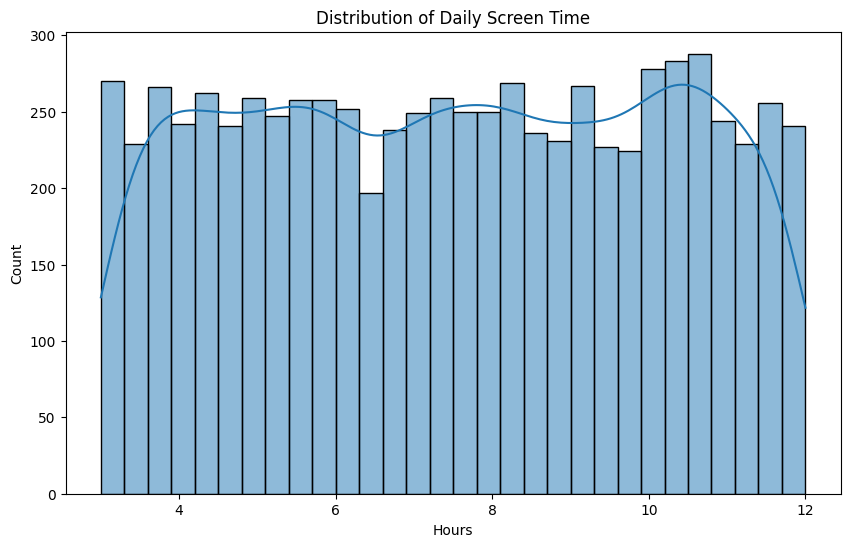

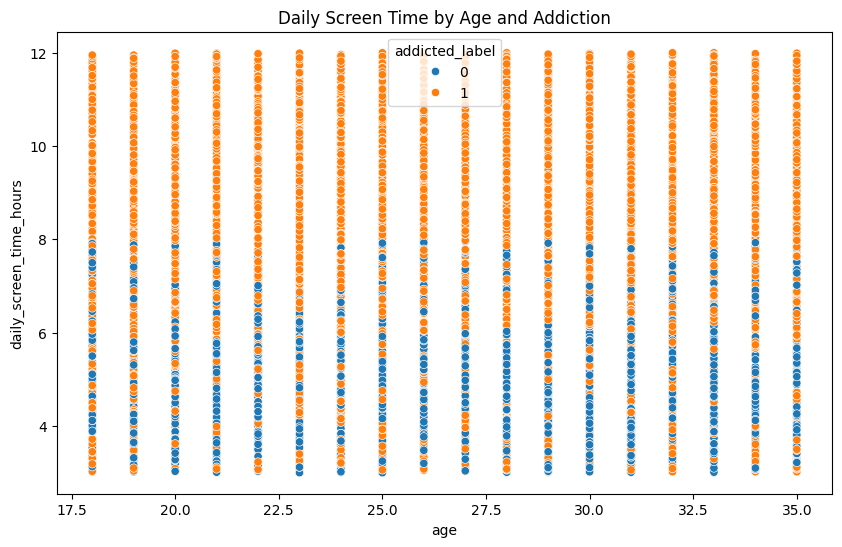

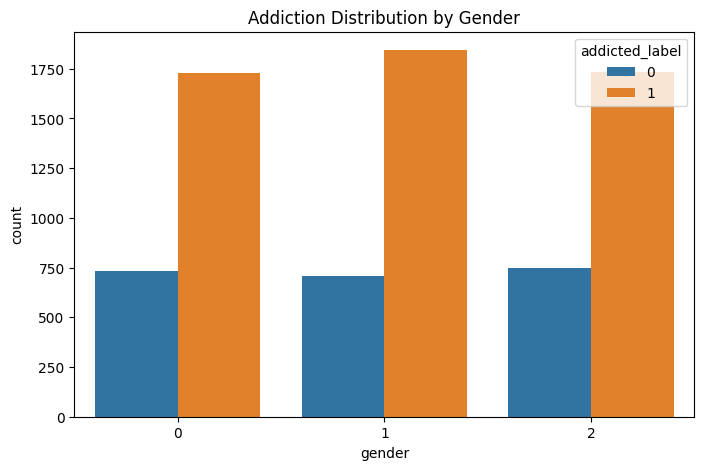

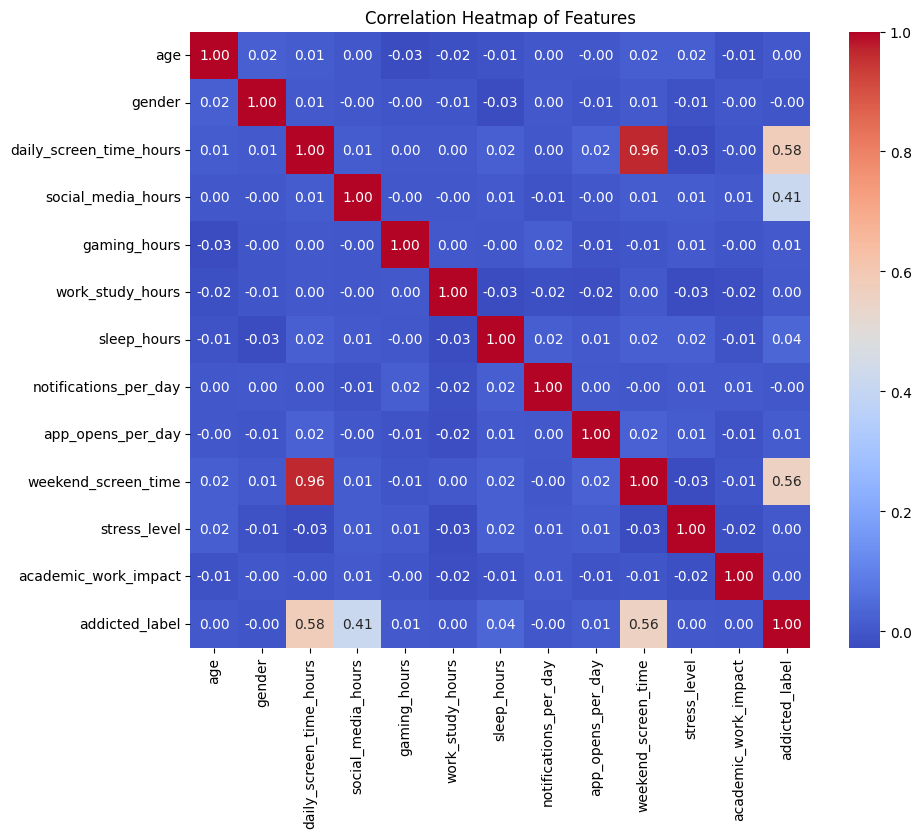

In [5]:


# Distribution of Daily Screen Time
plt.figure(figsize=(10,6))
sns.histplot(df['daily_screen_time_hours'], bins=30, kde=True)
plt.title("Distribution of Daily Screen Time")
plt.xlabel("Hours")
plt.ylabel("Count")
plt.show()

# Screen Time vs Age
plt.figure(figsize=(10,6))
sns.scatterplot(x='age', y='daily_screen_time_hours', hue='addicted_label', data=df)
plt.title("Daily Screen Time by Age and Addiction")
plt.show()

# Gender vs Addiction
plt.figure(figsize=(8,5))
sns.countplot(x='gender', hue='addicted_label', data=df)
plt.title("Addiction Distribution by Gender")
plt.show()

# Correlation Heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap of Features")
plt.show()

#  Prepare Data

In [6]:
X = df.drop(columns=['addicted_label'])
y = df['addicted_label']

# Balance classes with SMOTE
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X, y)

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_res, y_res, test_size=0.2, random_state=42, stratify=y_res
)

# Feature Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

#   Models

In [7]:


models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=300, learning_rate=0.05, max_depth=6, random_state=42),
    "XGBoost": XGBClassifier(n_estimators=500, learning_rate=0.05, max_depth=6, use_label_encoder=False, eval_metric='logloss', random_state=42),
    "LightGBM": LGBMClassifier(n_estimators=500, learning_rate=0.05, max_depth=6, random_state=42,verbosity=-1 )
}

#  Train, Predict & Compare Models


Logistic Regression Accuracy: 0.9016
Logistic Regression Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.91      0.90      1062
           1       0.91      0.89      0.90      1062

    accuracy                           0.90      2124
   macro avg       0.90      0.90      0.90      2124
weighted avg       0.90      0.90      0.90      2124



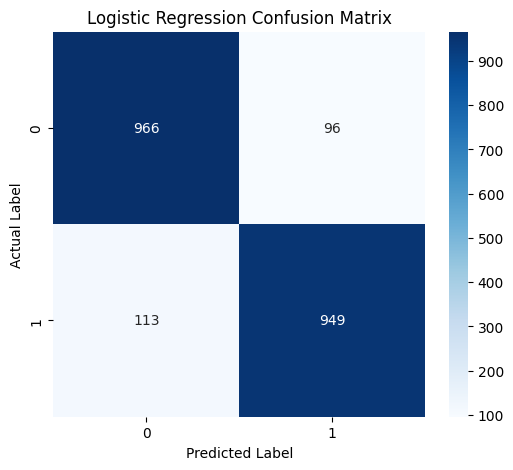


Random Forest Accuracy: 0.9572
Random Forest Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.98      0.96      1062
           1       0.98      0.93      0.96      1062

    accuracy                           0.96      2124
   macro avg       0.96      0.96      0.96      2124
weighted avg       0.96      0.96      0.96      2124



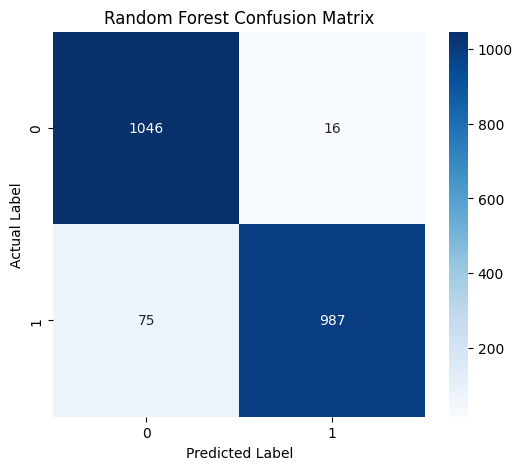


Gradient Boosting Accuracy: 0.9600
Gradient Boosting Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.98      0.96      1062
           1       0.98      0.94      0.96      1062

    accuracy                           0.96      2124
   macro avg       0.96      0.96      0.96      2124
weighted avg       0.96      0.96      0.96      2124



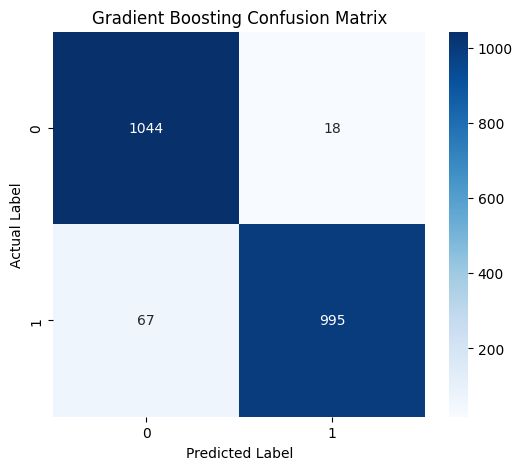

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [15:42:27] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



XGBoost Accuracy: 0.9609
XGBoost Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.98      0.96      1062
           1       0.98      0.94      0.96      1062

    accuracy                           0.96      2124
   macro avg       0.96      0.96      0.96      2124
weighted avg       0.96      0.96      0.96      2124



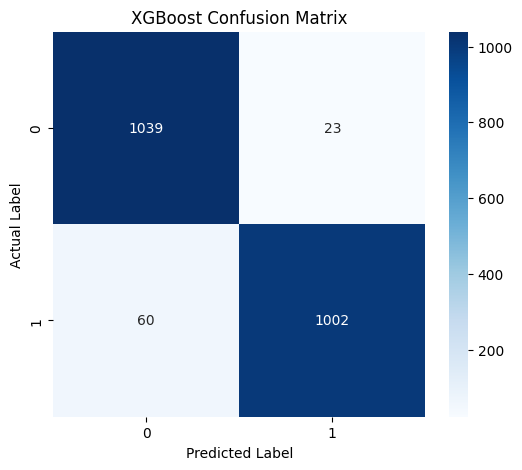


LightGBM Accuracy: 0.9605
LightGBM Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.98      0.96      1062
           1       0.98      0.94      0.96      1062

    accuracy                           0.96      2124
   macro avg       0.96      0.96      0.96      2124
weighted avg       0.96      0.96      0.96      2124



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


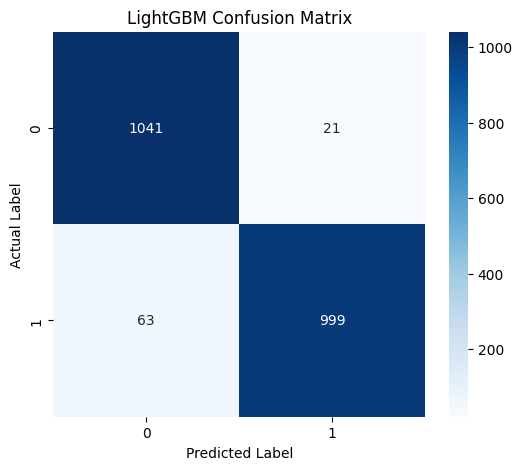

In [8]:

accuracy_results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    accuracy_results[name] = acc
    print(f"\n{name} Accuracy: {acc:.4f}")
    print(f"{name} Classification Report:\n", classification_report(y_test, y_pred))
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"{name} Confusion Matrix")
    plt.xlabel("Predicted Label")
    plt.ylabel("Actual Label")
    plt.show()


#  Compare Model Accuracies

/tmp/ipykernel_17/2659844475.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Accuracy', y='Model', data=acc_df, palette='viridis')


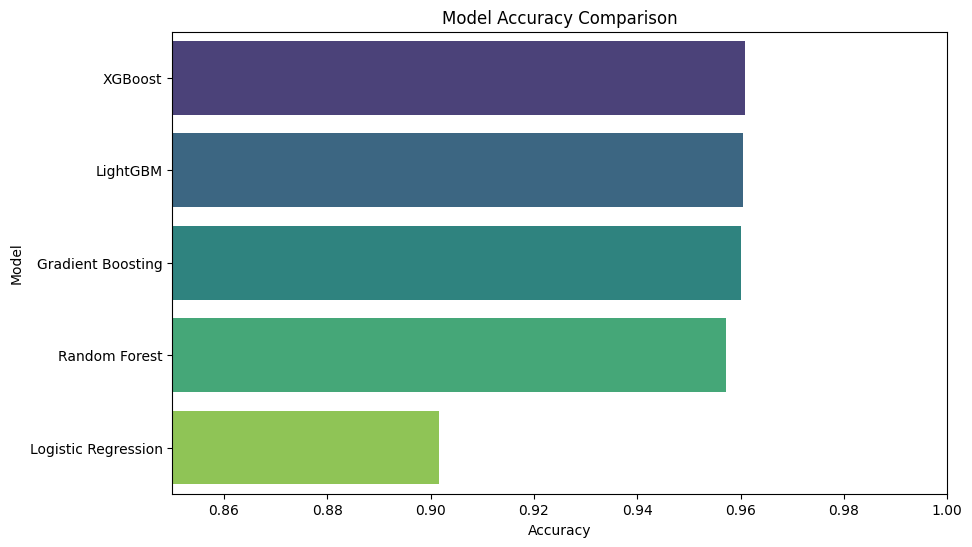

In [9]:

acc_df = pd.DataFrame(list(accuracy_results.items()), columns=['Model', 'Accuracy']).sort_values(by='Accuracy', ascending=False)
plt.figure(figsize=(10,6))
sns.barplot(x='Accuracy', y='Model', data=acc_df, palette='viridis')
plt.title("Model Accuracy Comparison")
plt.xlim(0.85,1.0)
plt.show()

#  Feature Importance for Best Model 

/tmp/ipykernel_17/3818790101.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_importance.values, y=feature_importance.index, palette="viridis")


Best Model: XGBoost


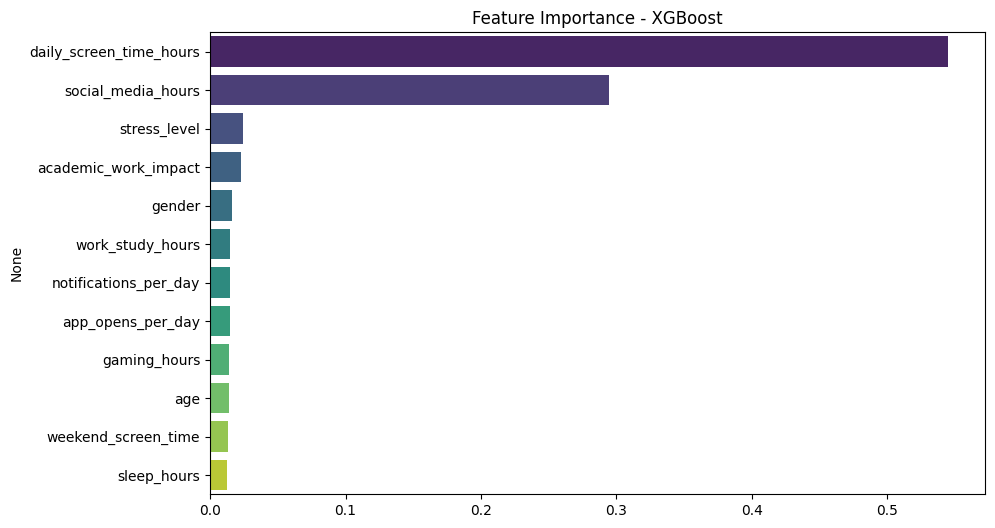

In [10]:
best_model_name = acc_df.iloc[0]['Model']
print(f"Best Model: {best_model_name}")

best_model = models[best_model_name]

# If model supports feature_importances_ (tree-based)
if hasattr(best_model, 'feature_importances_'):
    feature_importance = pd.Series(best_model.feature_importances_, index=X.columns).sort_values(ascending=False)
    plt.figure(figsize=(10,6))
    sns.barplot(x=feature_importance.values, y=feature_importance.index, palette="viridis")
    plt.title(f"Feature Importance - {best_model_name}")
    plt.show()



# Overall Summary

**What we mainly do:**

We analyze the dataset using data preprocessing, exploratory data analysis (EDA), visualization, and multiple machine learning models to understand patterns and make predictions.

**Why we do it:**

Traditional analysis cannot easily capture complex relationships in data. AI and machine learning help find hidden patterns, trends, and important features that influence the outcome.

**What we can achieve:**

- Build accurate prediction models

- Compare different algorithms to find the best one

- Generate useful insights from the data

- Support better data-driven decisions and future improvements.